### Замер времени выполения

In [15]:
%load_ext autotime
%matplotlib inline

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 1.1 ms (started: 2026-05-26 15:27:50 +03:00)


In [16]:
import time

start_time = time.perf_counter()

time: 417 μs (started: 2026-05-26 15:27:50 +03:00)


### Подключаем основные модули

In [17]:
import socket
from pathlib import Path

import chdb
import matplotlib.pyplot as plt
import my_modules.my_modules as mm
import pandas as pd
import seaborn as sns
from chdb import datastore as ds
from IPython.display import display


time: 427 μs (started: 2026-05-26 15:27:50 +03:00)


### Подключаемся к база данных `clickhouse`

При использовании модуля `chdb` можно работать без подключения к базе (см. notebook `cars2_file.ipynb`).

Работа с файлом примерно в `2` раза медленнее, нежели работа с базой.

In [18]:
hostname = socket.gethostname()
host = "service.db_clickhouse"
if hostname == "home-NMH-WDX9":
    host = "localhost"

dsf = ds.DataStore.from_clickhouse(  # type: ignore
    host=host,
    port=9000,
    database="cars",
    password="",
    # table="car_sales"
)
cars = dsf.table("car_sales")

time: 604 μs (started: 2026-05-26 15:27:50 +03:00)


### Получение описательной статистики

In [19]:
with pd.option_context(
    "display.float_format",
    "{:.2f}".format,
    "display.expand_frame_repr",
    False,
):
    display(cars.describe()[["price", "year", "mileage", "power"]])

,price,year,mileage,power
count,1294757.00,724644.00,771799.00,1273353.00
mean,1444357.82,2009.68,154893.40,141.56
std,1970257.41,9.37,100738.34,65.64
min,270.00,1936.00,1000.00,1.00
25%,425000.00,2003.00,82000.00,98.00
50%,870000.00,2011.00,144000.00,128.00
75%,1765000.00,2017.00,211000.00,163.00
max,150000000.00,2023.00,1000000.00,1000.00


time: 1.19 s (started: 2026-05-26 15:27:50 +03:00)


In [20]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294757 entries, 0 to 1294756
Data columns (total 18 columns):
  #   Column                Non-Null Count    Dtype  
 --  --------------------  ----------------  -----  
  0   brand                 1294757 non-null  object
  1   name                  1294757 non-null  object
  2   bodyType              1294757 non-null  object
  3   color                 1257029 non-null  object
  4   fuelType              1289815 non-null  object
  5   year                  724644 non-null   uint32
  6   mileage               771799 non-null   uint32
  7   transmission          1289563 non-null  object
  8   power                 1273353 non-null  uint16
  9   price                 1294757 non-null  uint32
 10   vehicleConfiguration  724647 non-null   object
 11   engineName            720976 non-null   object
 12   engineDisplacement    717625 non-null   float64
 13   date                  1294757 non-null  datetime64[s]
 14   location              12

In [38]:
sql = "SELECT COUNT(*) FROM cars.car_sales;"  # noqa: S608
result = dsf.select(sql)
print(result.to_sql())
rows_count = result.result_rows[0][0]

sql = "DESCRIBE TABLE cars.car_sales"
result = dsf.query(sql).to_df().set_index("name")

cars_columns = result.index.to_list()

field_not_null_counts = {}
for column in cars_columns:
    sql = f"""SELECT
    count(*) as count_{column}
    FROM cars.car_sales
    WHERE {column} IS NOT NULL"""  # noqa: S608
    field_not_null_counts[column] = dsf.query(sql).result_rows[0][0]
df = pd.DataFrame.from_dict(
    field_not_null_counts, orient="index", columns=["Non-Null Count"]
)
df["Null Count"] = rows_count - df["Non-Null Count"]
df["Null Count %"] = round((df["Null Count"] * 100) / rows_count, 2)

rez = pd.concat([result, df], axis=1).reset_index().rename(columns={"index": "field"})
rez_styled = rez.style.map(mm.highlight_values, subset=["Null Count %"]).format({
    "Null Count %": "{:.2f}"
})

rez_styled

SELECT "SELECT COUNT(*) FROM cars.car_sales;"


KeyError: "Column 'result_rows' not found in DataFrame"

time: 100 ms (started: 2026-05-26 15:45:59 +03:00)


In [21]:
total_rows, total_null_val, types, table = mm.custom_info(cars)
with pd.option_context(
    "display.expand_frame_repr",
    False,
):
    display(table)
    print(
        f"Всего записей: {total_rows}, Null значений: {total_null_val}, Типы данных: {types}"
    )

,Column,Non-Null Count,Non-Null Count %,Null Count,Null Count %,Total Rows,Dtype
0,brand,1294757,100.000000,0,0.000000,1294757,object
1,name,1294757,100.000000,0,0.000000,1294757,object
2,bodyType,1294757,100.000000,0,0.000000,1294757,object
3,color,1257029,97.090000,37728,2.910000,1294757,object
4,fuelType,1289815,99.620000,4942,0.380000,1294757,object
5,year,724644,55.970000,570113,44.030000,1294757,uint32
6,mileage,771799,59.610000,522958,40.390000,1294757,uint32
7,transmission,1289563,99.600000,5194,0.400000,1294757,object
8,power,1273353,98.350000,21404,1.650000,1294757,uint16
9,price,1294757,100.000000,0,0.000000,1294757,uint32


Всего записей: 1294757, Null значений: 2923714, Типы данных: datetime64[s](2), float64(1), object(11), uint16(1), uint32(3)
time: 1.02 s (started: 2026-05-26 15:27:52 +03:00)


In [22]:
cars_colums = cars.columns.to_list()
cars_colums.remove("link")
cars_colums.remove("description")

dfs = []
sample_size_per_group = 10000

for group_id in range(1, 4):
    query = f"""
    WITH ranked AS (
        SELECT {",".join(cars_colums)}, NTILE(3) OVER (ORDER BY rand()) AS tile
        FROM cars.car_sales
    )
    SELECT * FROM ranked
    WHERE tile = {group_id}
    ORDER BY rand()
    LIMIT {sample_size_per_group}
    """

    # dfs.append(dsf.sql(query))
    dfs.append(chdb.query(query))


RuntimeError: Code: 81. DB::Exception: Database cars does not exist. (UNKNOWN_DATABASE)

time: 46.7 ms (started: 2026-05-26 15:27:53 +03:00)


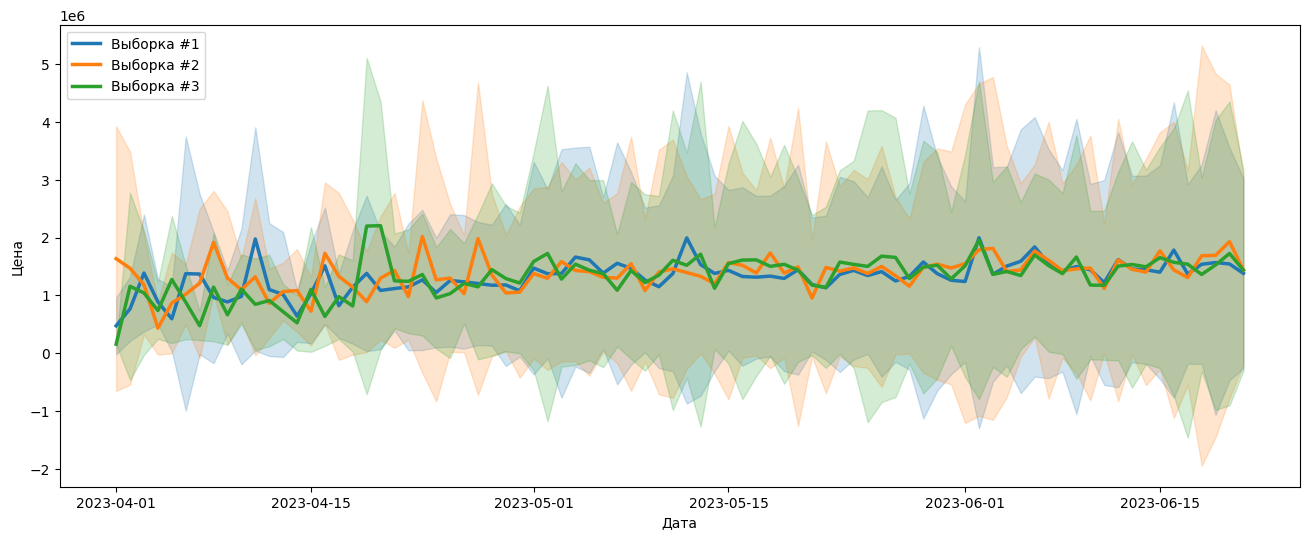

CPU times: user 947 ms, sys: 23.3 ms, total: 971 ms
Wall time: 989 ms
time: 990 ms (started: 2026-05-26 14:58:08 +03:00)


In [ ]:
%%time
plt.figure(figsize=(16, 6))
for idx, df_number in enumerate(dfs, 1):
    sns.lineplot(
        x="date",
        y="price",
        data=df_number,
        linewidth=2.5,
        errorbar="sd",
        label=f"Выборка #{idx}",
    )
plt.xlabel("Дата")
plt.ylabel("Цена")
plt.show()

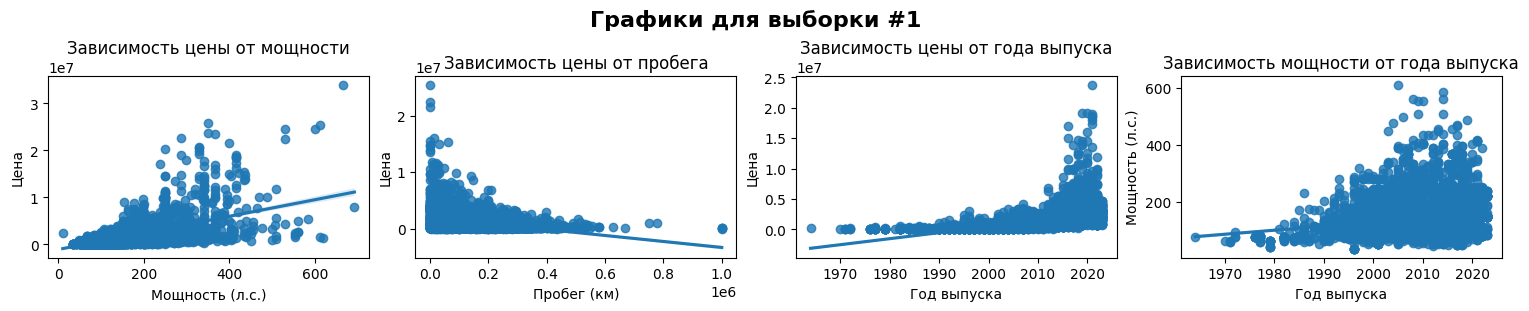

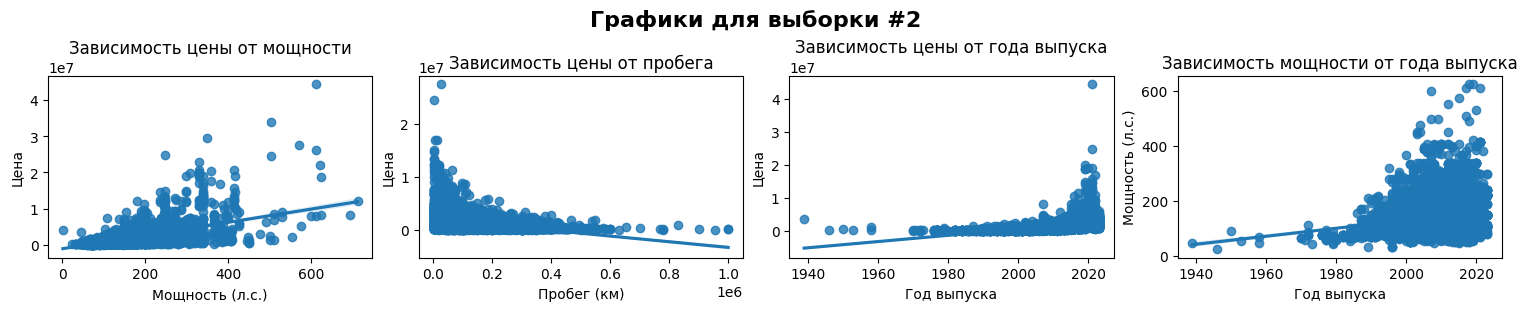

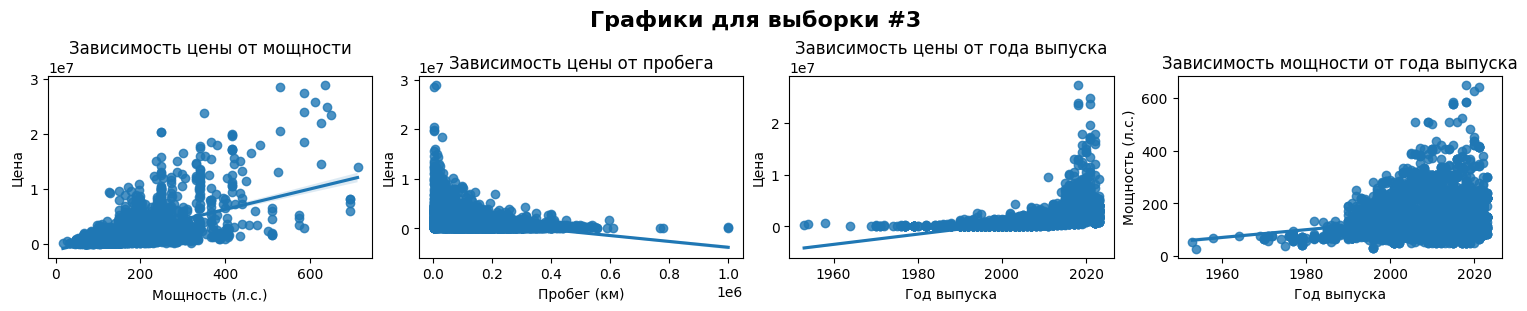

CPU times: user 4.54 s, sys: 93.1 ms, total: 4.63 s
Wall time: 4.63 s
time: 4.64 s (started: 2026-05-26 14:58:09 +03:00)


In [ ]:
%%time

for idx, df_number in enumerate(dfs):
    fig, axes = plt.subplots(1, 4, figsize=(15, 3), constrained_layout=True)
    fig.suptitle(f"Графики для выборки #{idx + 1}", fontsize=16, fontweight="bold")

    # График 1: power vs price
    sns.regplot(data=dfs[idx], x="power", y="price", ax=axes[0])
    axes[0].set_xlabel("Мощность (л.с.)")
    axes[0].set_ylabel("Цена")
    axes[0].set_title("Зависимость цены от мощности")

    # График 2: mileage vs price
    sns.regplot(data=dfs[idx], x="mileage", y="price", ax=axes[1])
    axes[1].set_xlabel("Пробег (км)")
    axes[1].set_ylabel("Цена")
    axes[1].set_title("Зависимость цены от пробега")

    # График 3: year vs price
    sns.regplot(data=dfs[idx], x="year", y="price", ax=axes[2])
    axes[2].set_xlabel("Год выпуска")
    axes[2].set_ylabel("Цена")
    axes[2].set_title("Зависимость цены от года выпуска")

    # График 4: year vs power
    sns.regplot(data=dfs[idx], x="year", y="power", ax=axes[3])
    axes[3].set_xlabel("Год выпуска")
    axes[3].set_ylabel("Мощность (л.с.)")
    axes[3].set_title("Зависимость мощности от года выпуска")

plt.show()


In [ ]:
# # dsf["car_sales"]["year"].isnull().sum()
# df_test = cars[cars["year"].isnull()]
# df_test

time: 234 μs (started: 2026-05-26 14:58:14 +03:00)


In [ ]:
# df1 = dfs[0][['price', 'year', 'mileage', 'power']]
# g = sns.PairGrid(df1, diag_sharey=False)
# g.map_upper(sns.regplot)
# g.map_lower(sns.regplot)
# g.map_diag(sns.kdeplot, lw=2)
# plt.show()

time: 246 μs (started: 2026-05-26 14:58:14 +03:00)


In [ ]:
end_time = time.perf_counter()
total_time = end_time - start_time
print(f"Общее время выполнения: {total_time:.4f} секунд")

Общее время выполнения: 16.4223 секунд
time: 761 μs (started: 2026-05-26 14:58:14 +03:00)
